## Face Recognition — PCA

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pca import PCA
from kmeans import KMeans, fit_cluster_label_mapping, predict_labels_from_clusters
import os

np.random.seed(42)

data = np.load('face_data.npz')
X_train, X_test = data['X_train'], data['X_test']
y_train, y_test = data['y_train'], data['y_test']

os.makedirs('figures', exist_ok=True)

### Fit PCA on Training Data (runs once, saves eigenvalues)

In [2]:
pca = PCA()
pca.fit(X_train)  # computes and saves eigenvalues.npy & eigenvectors.npy

### Load from saved files (skip fit next time)

In [3]:
pca = PCA()
pca.load()
pca.mean = X_train.mean(axis=0)  # mean still needed for projection

### Dimensionality for each variance threshold

α=0.80 → 36 components
α=0.85 → 52 components
α=0.90 → 76 components
α=0.95 → 115 components


### Visualize Eigenfaces (top 10 principal components)

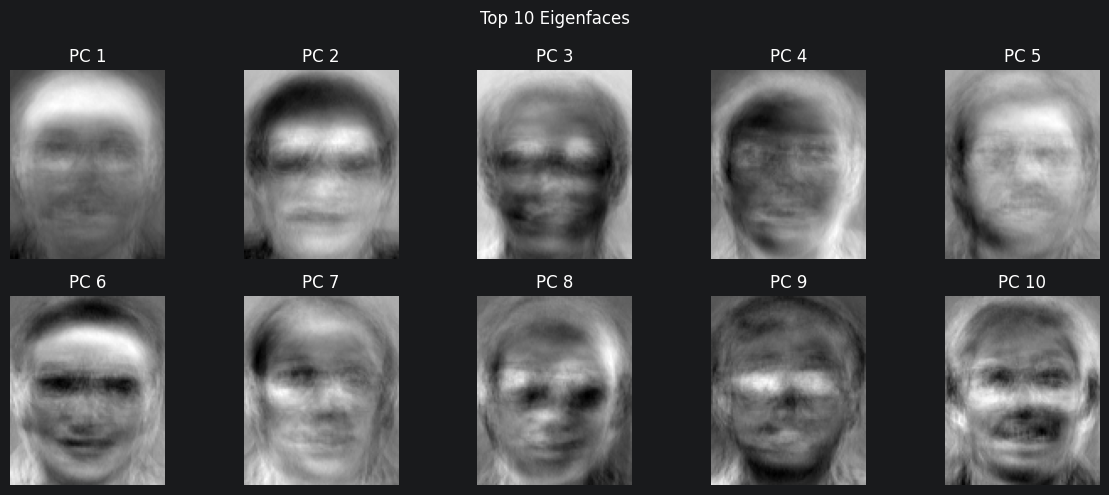

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    eigenface = pca.eigenvectors[i].reshape(112, 92)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f'PC {i+1}')
    ax.axis('off')
plt.suptitle('Top 10 Eigenfaces')
plt.tight_layout()
plt.savefig('figures/eigenfaces.png', dpi=200, bbox_inches='tight')
plt.show()

### Visualize Sample Faces Reconstructed from PCA subspace

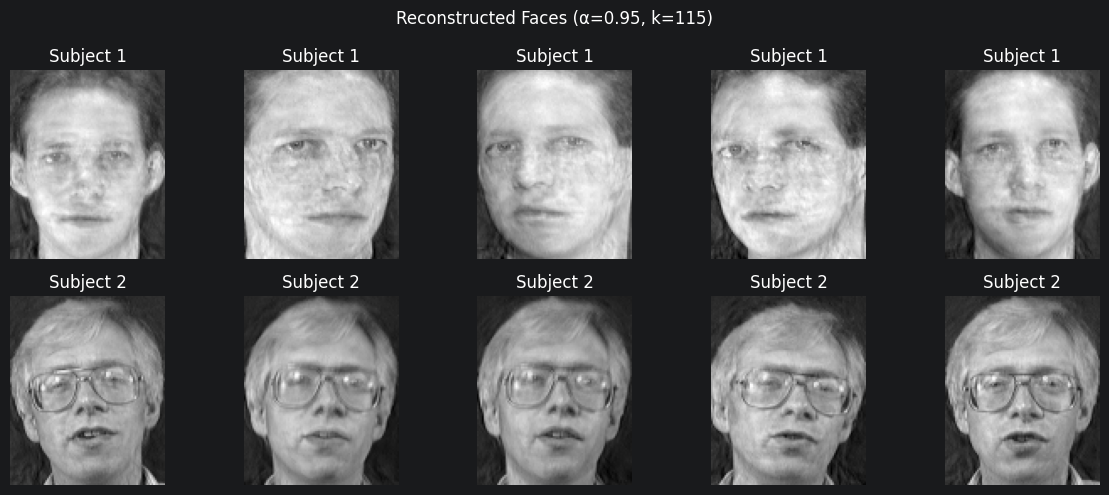

In [6]:
alpha = 0.95
k = pca.n_components_for_variance(alpha)
X_train_pca = pca.project(X_train, alpha)  # (200, k)

# Reconstruct back to image space
X_reconstructed = X_train_pca @ pca.eigenvectors[:k] + pca.mean

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_reconstructed[i].reshape(112, 92), cmap='gray')
    ax.set_title(f'Subject {y_train[i]}')
    ax.axis('off')
plt.suptitle(f'Reconstructed Faces (α={alpha}, k={k})')
plt.tight_layout()
plt.savefig('figures/reconstructions.png', dpi=200, bbox_inches='tight')
plt.show()

### Project Train & Test sets for all thresholds

In [16]:
projected = {}
for alpha in alphas:
    k = pca.n_components_for_variance(alpha)
    projected[alpha] = {
        'X_train': pca.project(X_train, alpha),
        'X_test' : pca.project(X_test,  alpha),
        'k'      : k
    }
    print(f'α={alpha} → X_train: {projected[alpha]["X_train"].shape}, X_test: {projected[alpha]["X_test"].shape}')

α=0.8 → X_train: (200, 36), X_test: (200, 36)
α=0.85 → X_train: (200, 52), X_test: (200, 52)
α=0.9 → X_train: (200, 76), X_test: (200, 76)
α=0.95 → X_train: (200, 115), X_test: (200, 115)


### K-Means grid search on PCA-reduced data (Accuracy + Weighted F1 + Confusion Matrix)

alpha	K	train_acc	test_acc	test_f1_w
0.80	20	0.4750		0.4500		0.3271
0.80	40	0.6900		0.5900		0.5204
0.80	60	0.8500		0.7900		0.7753
0.85	20	0.4700		0.4400		0.3223
0.85	40	0.6950		0.6050		0.5409
0.85	60	0.8050		0.7200		0.7021
0.90	20	0.4600		0.4500		0.3264
0.90	40	0.6600		0.5600		0.4837
0.90	60	0.8050		0.7200		0.6956
0.95	20	0.4600		0.4400		0.3177
0.95	40	0.6100		0.5200		0.4384
0.95	60	0.7950		0.7250		0.6967

Best by TRAIN accuracy:
alpha=0.80, K=60, train_acc=0.8500, test_acc=0.7900, test_f1_w=0.7753

Confusion matrix (test):
[[4 0 0 ... 0 0 0]
 [0 5 0 ... 0 0 0]
 [0 0 4 ... 0 0 0]
 ...
 [0 0 0 ... 5 0 0]
 [0 0 0 ... 0 5 0]
 [0 0 0 ... 0 0 3]]


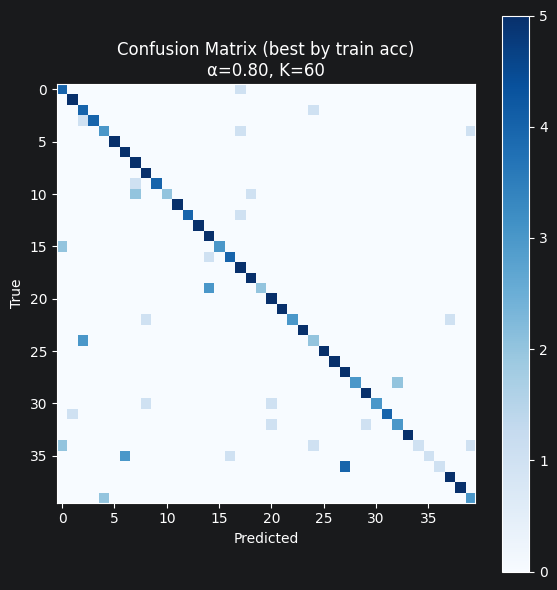

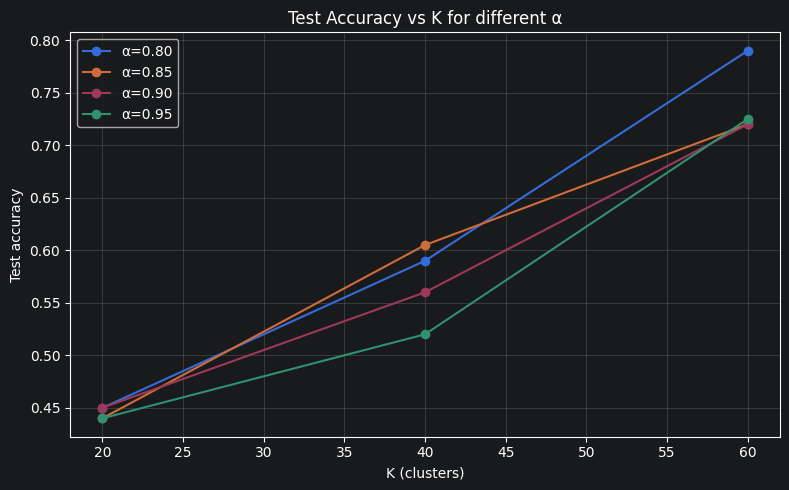

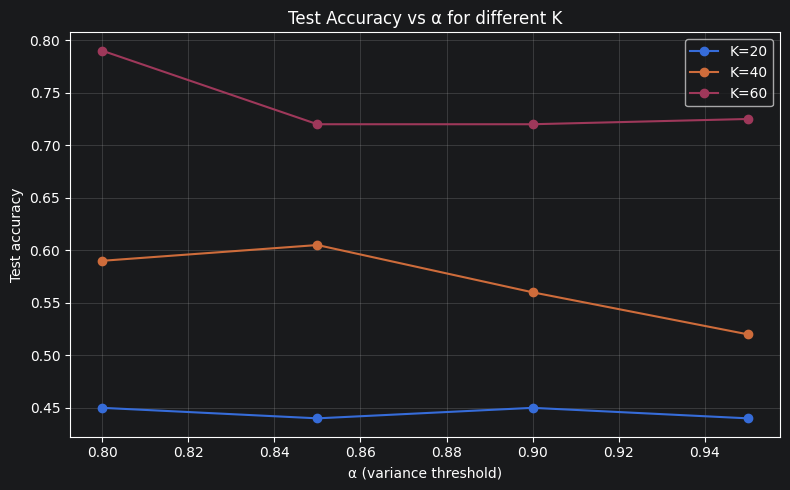

In [8]:
# Simple metrics (no sklearn required)

def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def confusion_matrix(y_true, y_pred, labels):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    labels = np.asarray(labels)
    label_to_index = {int(label): idx for idx, label in enumerate(labels)}
    cm = np.zeros((labels.size, labels.size), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        if int(yt) in label_to_index and int(yp) in label_to_index:
            cm[label_to_index[int(yt)], label_to_index[int(yp)]] += 1
    return cm


def f1_score_weighted(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels)
    supports = cm.sum(axis=1)
    total = supports.sum()
    f1s = []
    weights = []
    for i in range(len(labels)):
        tp = cm[i, i]
        fp = int(cm[:, i].sum() - tp)
        fn = int(cm[i, :].sum() - tp)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        f1s.append(f1)
        weights.append(supports[i])
    if total == 0:
        return 0.0
    return float(np.sum(np.array(f1s) * np.array(weights)) / total)


alphas = [0.80, 0.85, 0.90, 0.95]
Ks = [20, 40, 60]

# Build PCA projections dict if not already created
projected = {}
for alpha in alphas:
    projected[alpha] = {
        'X_train': pca.project(X_train, alpha),
        'X_test': pca.project(X_test, alpha),
        'k': pca.n_components_for_variance(alpha)
    }

labels = np.unique(y_train)

# Grid search: choose best (alpha, K) by TRAIN accuracy
rows = []
best = {'train_acc': -1.0}

for alpha in alphas:
    Xtr = projected[alpha]['X_train']
    Xte = projected[alpha]['X_test']
    for k in Ks:
        km = KMeans(k=k, max_iters=10000, random_state=42)
        tr_clusters = km.fit_predict(Xtr)
        mapping = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred = predict_labels_from_clusters(tr_clusters, mapping, unknown_label=-1)
        train_acc = accuracy_score(y_train, y_tr_pred)

        te_clusters = km.predict(Xte)
        y_te_pred = predict_labels_from_clusters(te_clusters, mapping, unknown_label=-1)
        test_acc = accuracy_score(y_test, y_te_pred)
        test_f1 = f1_score_weighted(y_test, y_te_pred, labels)

        rows.append({
            'alpha': alpha,
            'K': k,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1_weighted': test_f1
        })

        if train_acc > best['train_acc']:
            best = {
                'alpha': alpha,
                'K': k,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'test_f1_weighted': test_f1,
                'y_test_pred': y_te_pred
            }

# Print table
print('alpha\tK\ttrain_acc\ttest_acc\ttest_f1_w')
for r in rows:
    print(f"{r['alpha']:.2f}\t{r['K']}\t{r['train_acc']:.4f}\t\t{r['test_acc']:.4f}\t\t{r['test_f1_weighted']:.4f}")

print('\nBest by TRAIN accuracy:')
print(f"alpha={best['alpha']:.2f}, K={best['K']}, train_acc={best['train_acc']:.4f}, test_acc={best['test_acc']:.4f}, test_f1_w={best['test_f1_weighted']:.4f}")

# Confusion matrix for best config on TEST
cm = confusion_matrix(y_test, best['y_test_pred'], labels)
print('\nConfusion matrix (test):')
print(cm)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (best by train acc)\nα={best['alpha']:.2f}, K={best['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.savefig('figures/cm_kmeans.png', dpi=200, bbox_inches='tight')
plt.show()

# Plot accuracy vs K (one curve per alpha) using TEST accuracy
plt.figure(figsize=(8, 5))
for alpha in alphas:
    accs = [next(r['test_acc'] for r in rows if r['alpha'] == alpha and r['K'] == k) for k in Ks]
    plt.plot(Ks, accs, marker='o', label=f'α={alpha:.2f}')
plt.xlabel('K (clusters)')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs K for different α')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_acc_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

# Plot accuracy vs alpha (one curve per K)
plt.figure(figsize=(8, 5))
for k in Ks:
    accs = [next(r['test_acc'] for r in rows if r['alpha'] == alpha and r['K'] == k) for alpha in alphas]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
plt.xlabel('α (variance threshold)')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs α for different K')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_acc_vs_alpha.png', dpi=200, bbox_inches='tight')
plt.show()


alpha	K	train_acc	test_acc	test_f1_w
0.80	20	0.3850		0.3150		0.2367
0.80	40	0.5550		0.4800		0.3836
0.80	60	0.7400		0.6250		0.6114
0.85	20	0.3850		0.3200		0.2368
0.85	40	0.5700		0.4800		0.3674
0.85	60	0.7250		0.6250		0.6036
0.90	20	0.3850		0.3150		0.2320
0.90	40	0.5600		0.4800		0.3671
0.90	60	0.7250		0.6200		0.5866
0.95	20	0.3750		0.3200		0.2386
0.95	40	0.5500		0.4750		0.3649
0.95	60	0.7200		0.5900		0.5673

Best GMM by TRAIN accuracy:
alpha=0.80, K=60, train_acc=0.7400, test_acc=0.6250, test_f1_w=0.6114

Confusion matrix (GMM test):
[[2 0 0 ... 0 0 0]
 [0 5 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 4 0 0]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 1]]


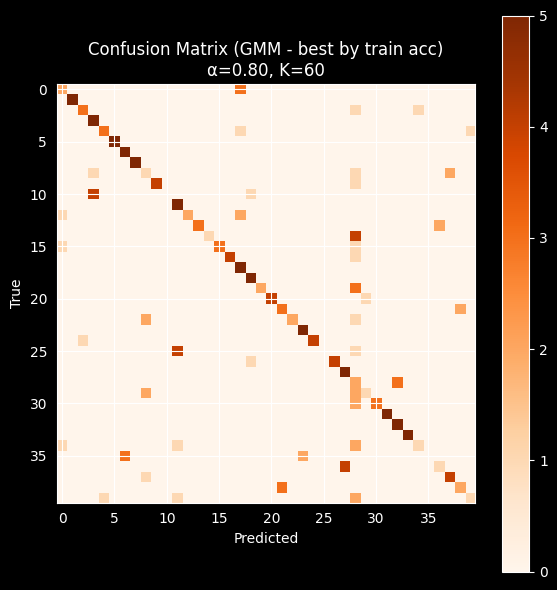

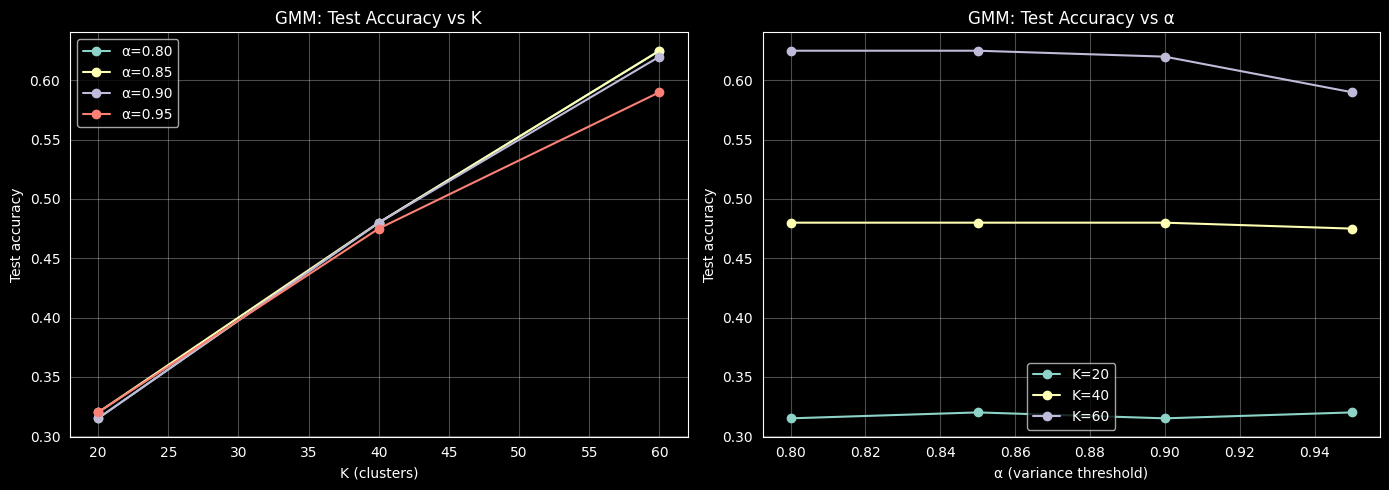


--- Comparison: K-Means vs GMM ---
Best K-Means Test Accuracy: 0.7900
Best GMM Test Accuracy:     0.6250


In [18]:
from gmm import GMM, fit_cluster_label_mapping, predict_labels_from_clusters

gmm_rows = []
best_gmm = {'train_acc': -1.0}

for alpha in alphas:
    Xtr = projected[alpha]['X_train']
    Xte = projected[alpha]['X_test']
    for k in Ks:
        gmm = GMM(k=k, max_iters=50, random_state=42)
        tr_clusters = gmm.fit_predict(Xtr)
        mapping = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred = predict_labels_from_clusters(tr_clusters, mapping, unknown_label=-1)
        train_acc = accuracy_score(y_train, y_tr_pred)

        te_clusters = gmm.predict(Xte)
        y_te_pred = predict_labels_from_clusters(te_clusters, mapping, unknown_label=-1)
        test_acc = accuracy_score(y_test, y_te_pred)
        test_f1 = f1_score_weighted(y_test, y_te_pred, labels)

        gmm_rows.append({
            'alpha': alpha,
            'K': k,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'test_f1_weighted': test_f1
        })

        if train_acc > best_gmm['train_acc']:
            best_gmm = {
                'alpha': alpha,
                'K': k,
                'train_acc': train_acc,
                'test_acc': test_acc,
                'test_f1_weighted': test_f1,
                'y_test_pred': y_te_pred
            }

print('alpha\tK\ttrain_acc\ttest_acc\ttest_f1_w')
for r in gmm_rows:
    print(f"{r['alpha']:.2f}\t{r['K']}\t{r['train_acc']:.4f}\t\t{r['test_acc']:.4f}\t\t{r['test_f1_weighted']:.4f}")

print('\nBest GMM by TRAIN accuracy:')
print(f"alpha={best_gmm['alpha']:.2f}, K={best_gmm['K']}, train_acc={best_gmm['train_acc']:.4f}, test_acc={best_gmm['test_acc']:.4f}, test_f1_w={best_gmm['test_f1_weighted']:.4f}")

cm_gmm = confusion_matrix(y_test, best_gmm['y_test_pred'], labels)
print('\nConfusion matrix (GMM test):')
print(cm_gmm)

plt.figure(figsize=(6, 6))
plt.imshow(cm_gmm, cmap='Oranges')
plt.title(f"Confusion Matrix (GMM - best by train acc)\nα={best_gmm['alpha']:.2f}, K={best_gmm['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.savefig('figures/cm_gmm.png', dpi=200, bbox_inches='tight')
plt.show()

# GMM: Test Accuracy vs K (one curve per α)
plt.figure(figsize=(8, 5))
for alpha in alphas:
    accs = [next(r['test_acc'] for r in gmm_rows if r['alpha'] == alpha and r['K'] == k) for k in Ks]
    plt.plot(Ks, accs, marker='o', label=f'α={alpha:.2f}')
plt.xlabel('K (clusters)')
plt.ylabel('Test accuracy')
plt.title('GMM: Test Accuracy vs K')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/gmm_acc_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

# GMM: Test Accuracy vs α (one curve per K)
plt.figure(figsize=(8, 5))
for k in Ks:
    accs = [next(r['test_acc'] for r in gmm_rows if r['alpha'] == alpha and r['K'] == k) for alpha in alphas]
    plt.plot(alphas, accs, marker='o', label=f'K={k}')
plt.xlabel('α (variance threshold)')
plt.ylabel('Test accuracy')
plt.title('GMM: Test Accuracy vs α')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/gmm_acc_vs_alpha.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n--- Comparison: K-Means vs GMM ---")
print(f"Best K-Means Test Accuracy: {best['test_acc']:.4f}")
print(f"Best GMM Test Accuracy:     {best_gmm['test_acc']:.4f}")


## Bonus — Autoencoder Dimensionality Reduction

Train a simple single-hidden-layer autoencoder on the raw pixel data.
We match each encoding dimension to the PCA variance threshold (α = 0.80, 0.85, 0.90, 0.95)
so results are directly comparable. Then apply K-Means and GMM with K = 20, 40, 60.

In [40]:
import importlib
import autoencoder
importlib.reload(autoencoder)
from autoencoder import Autoencoder


In [41]:
from autoencoder import Autoencoder
from kmeans import KMeans, fit_cluster_label_mapping, predict_labels_from_clusters
from gmm import GMM

alphas = [0.80, 0.85, 0.90, 0.95]
Ks     = [20, 40, 60]

# Map each alpha to its PCA dimensionality
alpha_to_dim = {alpha: pca.n_components_for_variance(alpha) for alpha in alphas}
print('Encoding dims per alpha:')
for alpha, dim in alpha_to_dim.items():
    print(f'  alpha={alpha:.2f} -> {dim} dims')


Encoding dims per alpha:
  alpha=0.80 -> 36 dims
  alpha=0.85 -> 52 dims
  alpha=0.90 -> 76 dims
  alpha=0.95 -> 115 dims


In [42]:
ae_models  = {}
ae_encoded = {}  # {alpha: (X_train_ae, X_test_ae)}

for alpha in alphas:
    dim = alpha_to_dim[alpha]
    print(f'\n=== Training AE: encoding_dim={dim} (alpha={alpha:.2f}) ===')
    ae = Autoencoder(input_dim=10304, encoding_dim=dim, learning_rate=0.001, epochs=50, batch_size=16)
    ae.fit(X_train)
    ae_models[alpha] = ae
    ae_encoded[alpha] = (ae.encode(X_train), ae.encode(X_test))
    print(f'  Train encoded shape: {ae_encoded[alpha][0].shape}')



=== Training AE: encoding_dim=36 (alpha=0.80) ===
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 404ms/step - loss: 0.0312
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - loss: 0.0252
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - loss: 0.0233
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 393ms/step - loss: 0.0213
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 438ms/step - loss: 0.0205
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - loss: 0.0201
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - loss: 0.0197
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step - loss: 0.0192
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - loss: 0.0193
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step - loss: 0.0184
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - loss: 0.0174
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - loss: 0.0170
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - loss: 0.0160
Epoch 14/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 367ms/step - loss: 0.0150
Epoch

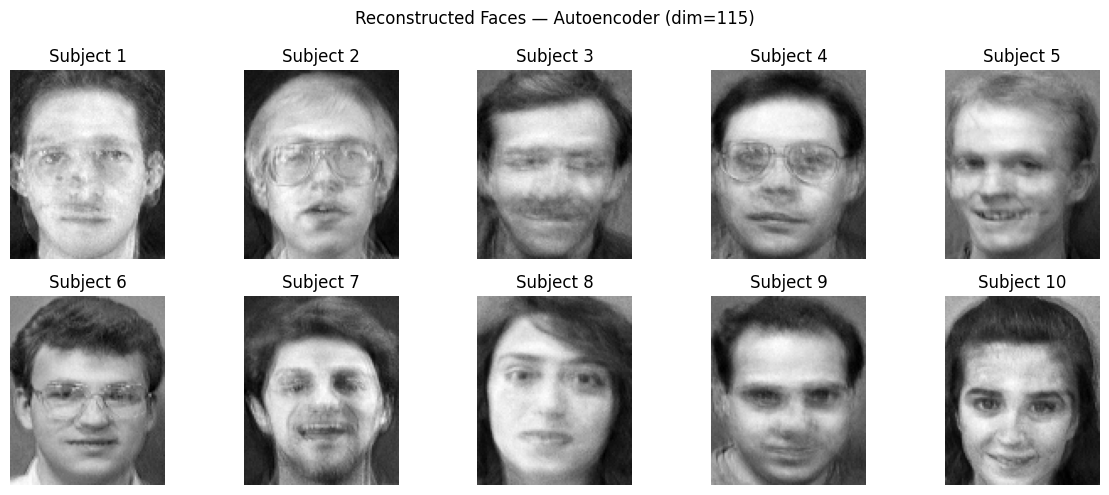

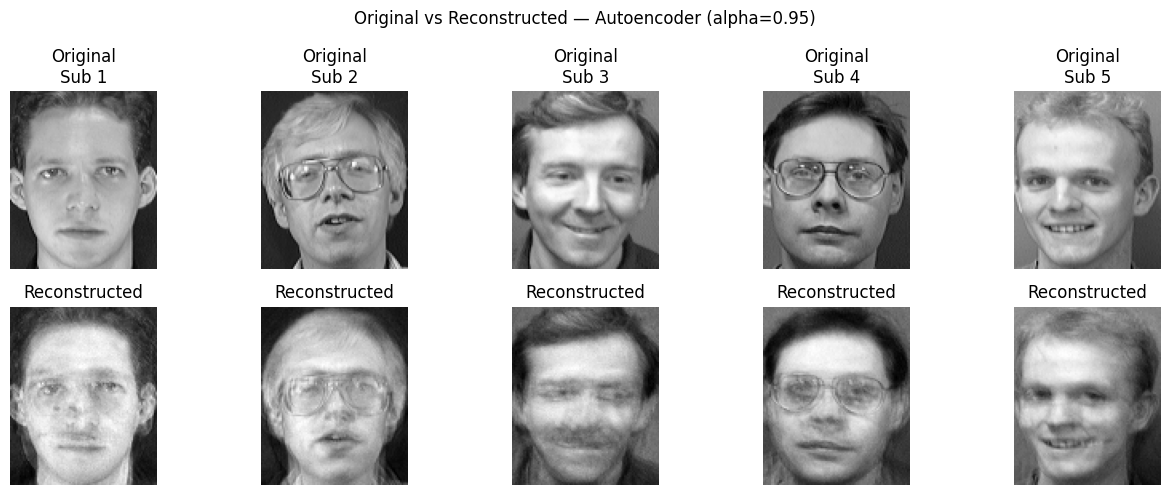

In [43]:
ae95 = ae_models[0.95]
X_train_ae95, _ = ae_encoded[0.95]
X_recon = ae95.decode(X_train_ae95)

# Normalize X_train to [0,1] for display to match reconstructed range
X_train_display = (X_train - X_train.min()) / (X_train.max() - X_train.min())

# Pick one sample per subject
n_show = 10
seen = set()
sample_indices = []
for idx, label in enumerate(y_train):
    if label not in seen:
        seen.add(label)
        sample_indices.append(idx)
    if len(sample_indices) == n_show:
        break

# Grid of reconstructions — 10 different subjects
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_recon[idx].reshape(112, 92), cmap='gray')
    ax.set_title(f'Subject {y_train[idx]}')
    ax.axis('off')
plt.suptitle(f'Reconstructed Faces — Autoencoder (dim={alpha_to_dim[0.95]})')
plt.tight_layout()
plt.show()

# Side-by-side: Original vs Reconstructed — 5 different subjects
n_side = 5
fig, axes = plt.subplots(2, n_side, figsize=(13, 5))
for col, idx in enumerate(sample_indices[:n_side]):
    axes[0, col].imshow(X_train_display[idx].reshape(112, 92), cmap='gray')
    axes[0, col].set_title(f'Original\nSub {y_train[idx]}')
    axes[0, col].axis('off')
    axes[1, col].imshow(X_recon[idx].reshape(112, 92), cmap='gray')
    axes[1, col].set_title('Reconstructed')
    axes[1, col].axis('off')
plt.suptitle('Original vs Reconstructed — Autoencoder (alpha=0.95)')
plt.tight_layout()
plt.show()

In [44]:
labels_all = np.unique(y_train)

km_ae_rows = []
km_ae_best = {'train_acc': -1.0}

for alpha in alphas:
    Xtr_ae, Xte_ae = ae_encoded[alpha]
    for k in Ks:
        km = KMeans(k=k, max_iters=10000, random_state=42)
        tr_clusters = km.fit_predict(Xtr_ae)
        mapping = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred = predict_labels_from_clusters(tr_clusters, mapping)
        train_acc = accuracy_score(y_train, y_tr_pred)

        te_clusters = km.predict(Xte_ae)
        y_te_pred   = predict_labels_from_clusters(te_clusters, mapping)
        test_acc    = accuracy_score(y_test, y_te_pred)
        test_f1     = f1_score_weighted(y_test, y_te_pred, labels_all)

        km_ae_rows.append({'alpha': alpha, 'K': k, 'dim': alpha_to_dim[alpha],
                           'train_acc': train_acc, 'test_acc': test_acc, 'test_f1': test_f1})

        if train_acc > km_ae_best['train_acc']:
            km_ae_best = {'alpha': alpha, 'K': k, 'train_acc': train_acc,
                          'test_acc': test_acc, 'test_f1': test_f1, 'y_te_pred': y_te_pred}

# Print results table
header = f"{'alpha':>6}  {'K':>4}  {'dim':>5}  {'train_acc':>10}  {'test_acc':>9}  {'test_f1_w':>9}"
print(header)
print('-' * len(header))
for r in km_ae_rows:
    print(f"{r['alpha']:.2f}    {r['K']:>4}  {r['dim']:>5}  "
          f"{r['train_acc']:>10.4f}  {r['test_acc']:>9.4f}  {r['test_f1']:>9.4f}")

print(f"\nBest KMeans-AE: alpha={km_ae_best['alpha']:.2f}, K={km_ae_best['K']}, "
      f"train={km_ae_best['train_acc']:.4f}, test={km_ae_best['test_acc']:.4f}, "
      f"f1={km_ae_best['test_f1']:.4f}")


 alpha     K    dim   train_acc   test_acc  test_f1_w
-----------------------------------------------------
0.80      20     36      0.4150     0.3150     0.2122
0.80      40     36      0.6150     0.5000     0.4354
0.80      60     36      0.7350     0.5800     0.5529
0.85      20     52      0.4450     0.3650     0.2505
0.85      40     52      0.6600     0.5400     0.4882
0.85      60     52      0.7300     0.6150     0.5888
0.90      20     76      0.4200     0.3450     0.2323
0.90      40     76      0.6350     0.5200     0.4778
0.90      60     76      0.7350     0.6150     0.5850
0.95      20    115      0.4200     0.3600     0.2419
0.95      40    115      0.6500     0.5200     0.4678
0.95      60    115      0.7400     0.5850     0.5617

Best KMeans-AE: alpha=0.95, K=60, train=0.7400, test=0.5850, f1=0.5617


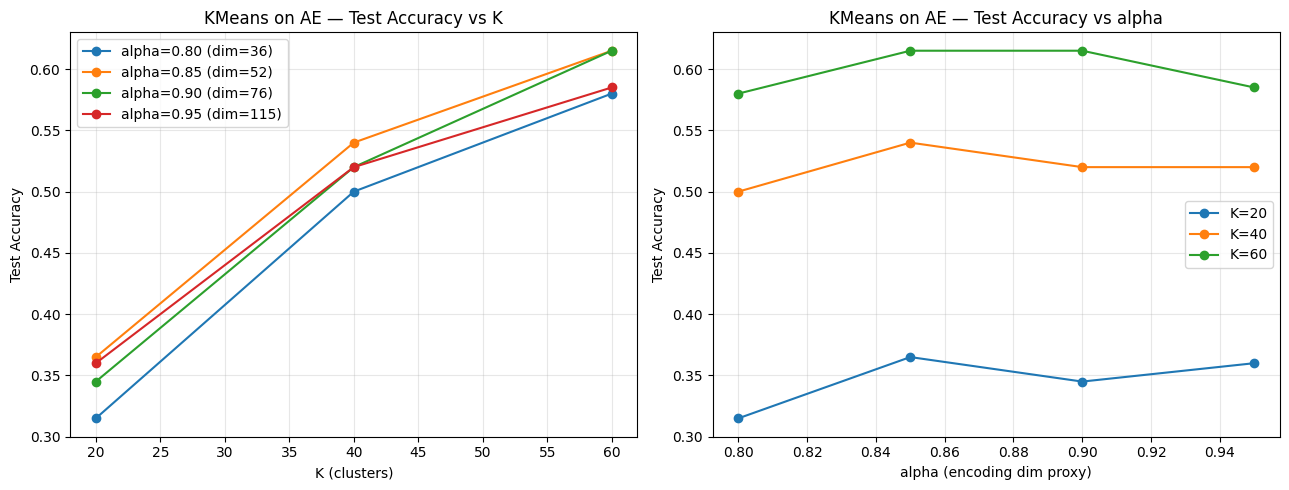

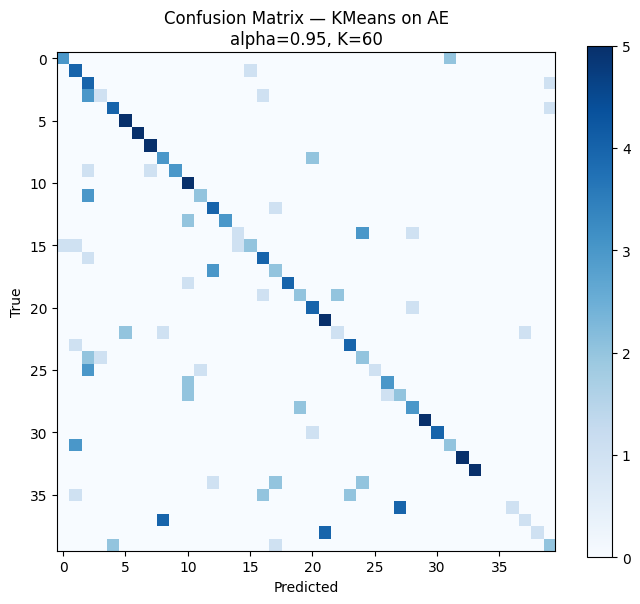

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy vs K
ax = axes[0]
for alpha in alphas:
    accs = [r['test_acc'] for r in km_ae_rows if r['alpha'] == alpha]
    ax.plot(Ks, accs, marker='o', label=f'alpha={alpha:.2f} (dim={alpha_to_dim[alpha]})')
ax.set_xlabel('K (clusters)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KMeans on AE — Test Accuracy vs K')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy vs alpha
ax = axes[1]
for k in Ks:
    accs = [r['test_acc'] for r in km_ae_rows if r['K'] == k]
    ax.plot(alphas, accs, marker='o', label=f'K={k}')
ax.set_xlabel('alpha (encoding dim proxy)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KMeans on AE — Test Accuracy vs alpha')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrix
cm_km_ae = confusion_matrix(y_test, km_ae_best['y_te_pred'], labels_all)
plt.figure(figsize=(7, 6))
plt.imshow(cm_km_ae, cmap='Blues')
plt.title(f"Confusion Matrix — KMeans on AE\nalpha={km_ae_best['alpha']:.2f}, K={km_ae_best['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.show()


In [46]:
gmm_ae_rows = []
gmm_ae_best = {'train_acc': -1.0}

for alpha in alphas:
    Xtr_ae, Xte_ae = ae_encoded[alpha]
    for k in Ks:
        print(f'GMM AE: alpha={alpha:.2f}, K={k} ...', end=' ', flush=True)
        gmm = GMM(k=k, max_iters=100, random_state=42)
        gmm.fit(Xtr_ae)

        tr_clusters = gmm.predict(Xtr_ae)
        mapping_g   = fit_cluster_label_mapping(tr_clusters, y_train)

        y_tr_pred_g = predict_labels_from_clusters(tr_clusters, mapping_g)
        train_acc_g = accuracy_score(y_train, y_tr_pred_g)

        te_clusters = gmm.predict(Xte_ae)
        y_te_pred_g = predict_labels_from_clusters(te_clusters, mapping_g)
        test_acc_g  = accuracy_score(y_test, y_te_pred_g)
        test_f1_g   = f1_score_weighted(y_test, y_te_pred_g, labels_all)

        gmm_ae_rows.append({'alpha': alpha, 'K': k, 'dim': alpha_to_dim[alpha],
                            'train_acc': train_acc_g, 'test_acc': test_acc_g, 'test_f1': test_f1_g})

        if train_acc_g > gmm_ae_best['train_acc']:
            gmm_ae_best = {'alpha': alpha, 'K': k, 'train_acc': train_acc_g,
                           'test_acc': test_acc_g, 'test_f1': test_f1_g, 'y_te_pred': y_te_pred_g}
        print(f'test_acc={test_acc_g:.4f}')

print()
header = f"{'alpha':>6}  {'K':>4}  {'dim':>5}  {'train_acc':>10}  {'test_acc':>9}  {'test_f1_w':>9}"
print(header)
print('-' * len(header))
for r in gmm_ae_rows:
    print(f"{r['alpha']:.2f}    {r['K']:>4}  {r['dim']:>5}  "
          f"{r['train_acc']:>10.4f}  {r['test_acc']:>9.4f}  {r['test_f1']:>9.4f}")

print(f"\nBest GMM-AE: alpha={gmm_ae_best['alpha']:.2f}, K={gmm_ae_best['K']}, "
      f"train={gmm_ae_best['train_acc']:.4f}, test={gmm_ae_best['test_acc']:.4f}, "
      f"f1={gmm_ae_best['test_f1']:.4f}")


GMM AE: alpha=0.80, K=20 ... test_acc=0.1100
GMM AE: alpha=0.80, K=40 ... test_acc=0.1050
GMM AE: alpha=0.80, K=60 ... test_acc=0.4300
GMM AE: alpha=0.85, K=20 ... test_acc=0.1200
GMM AE: alpha=0.85, K=40 ... test_acc=0.3600
GMM AE: alpha=0.85, K=60 ... test_acc=0.4200
GMM AE: alpha=0.90, K=20 ... test_acc=0.3200
GMM AE: alpha=0.90, K=40 ... test_acc=0.3600
GMM AE: alpha=0.90, K=60 ... test_acc=0.5450
GMM AE: alpha=0.95, K=20 ... test_acc=0.3100
GMM AE: alpha=0.95, K=40 ... test_acc=0.4800
GMM AE: alpha=0.95, K=60 ... test_acc=0.4850

 alpha     K    dim   train_acc   test_acc  test_f1_w
-----------------------------------------------------
0.80      20     36      0.3850     0.1100     0.0595
0.80      40     36      0.5100     0.1050     0.0739
0.80      60     36      0.6700     0.4300     0.3780
0.85      20     52      0.3900     0.1200     0.0885
0.85      40     52      0.5400     0.3600     0.3156
0.85      60     52      0.6600     0.4200     0.3646
0.90      20     76      0.

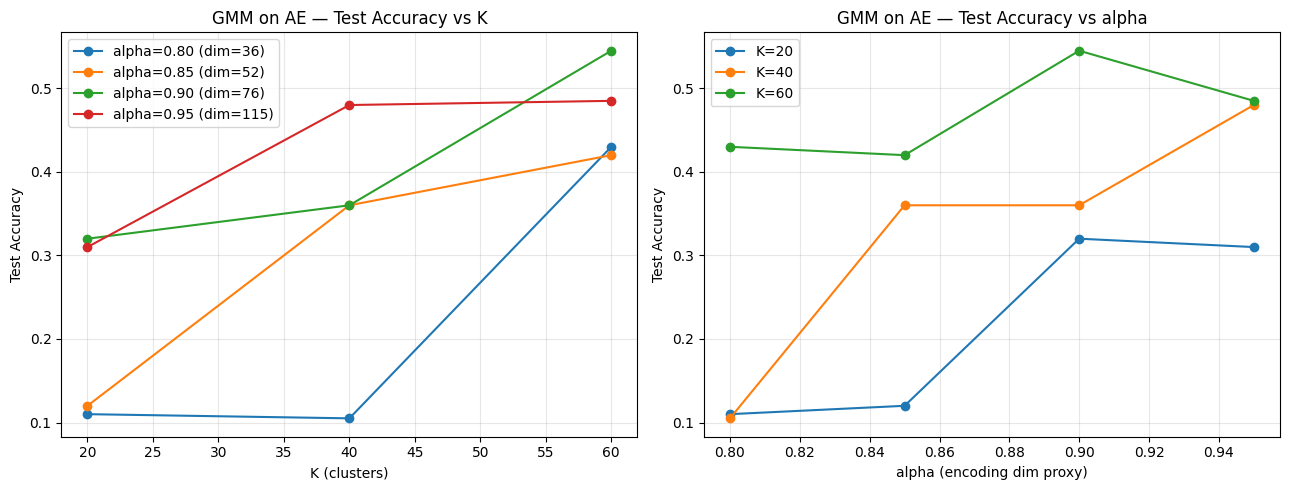

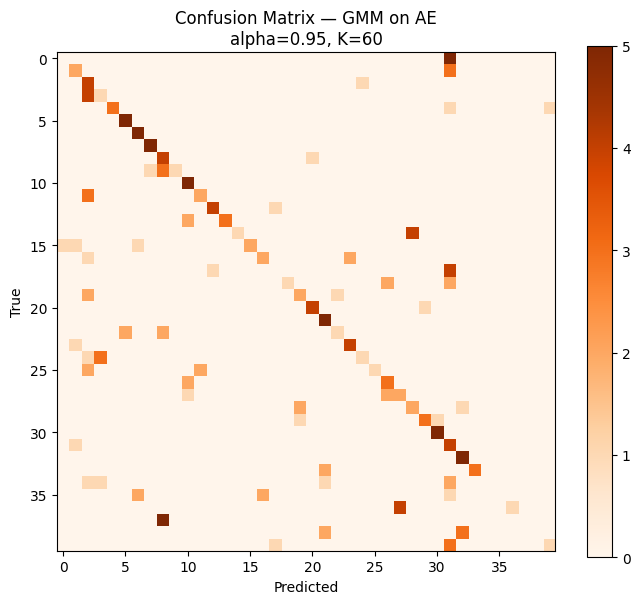

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for alpha in alphas:
    accs = [r['test_acc'] for r in gmm_ae_rows if r['alpha'] == alpha]
    ax.plot(Ks, accs, marker='o', label=f'alpha={alpha:.2f} (dim={alpha_to_dim[alpha]})')
ax.set_xlabel('K (clusters)')
ax.set_ylabel('Test Accuracy')
ax.set_title('GMM on AE — Test Accuracy vs K')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for k in Ks:
    accs = [r['test_acc'] for r in gmm_ae_rows if r['K'] == k]
    ax.plot(alphas, accs, marker='o', label=f'K={k}')
ax.set_xlabel('alpha (encoding dim proxy)')
ax.set_ylabel('Test Accuracy')
ax.set_title('GMM on AE — Test Accuracy vs alpha')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cm_gmm_ae = confusion_matrix(y_test, gmm_ae_best['y_te_pred'], labels_all)
plt.figure(figsize=(7, 6))
plt.imshow(cm_gmm_ae, cmap='Oranges')
plt.title(f"Confusion Matrix — GMM on AE\nalpha={gmm_ae_best['alpha']:.2f}, K={gmm_ae_best['K']}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.tight_layout()
plt.show()


         FINAL COMPARISON: PCA vs Autoencoder
Method                    Best alpha  Best K  Test Acc  Test F1-W
-----------------------------------------------------------------
KMeans on PCA                   0.80      60    0.7900     0.7753
KMeans on AE                    0.95      60    0.5850     0.5617
GMM on AE                       0.95      60    0.4850     0.4490


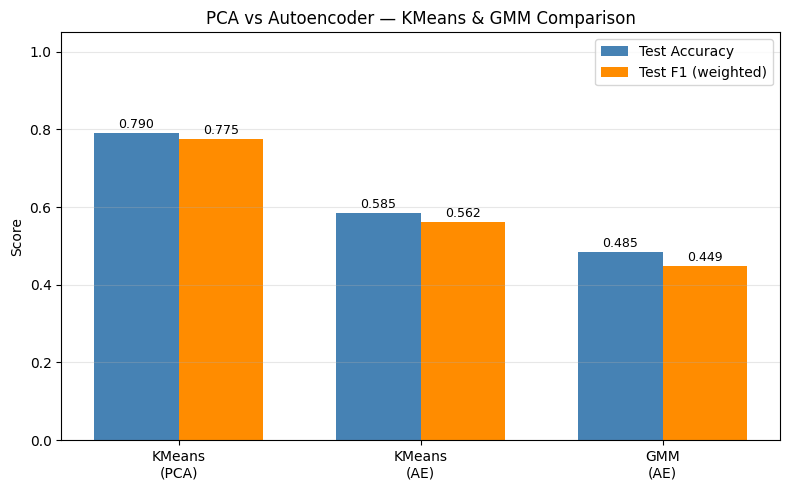

In [48]:
# 'best' dict was set by the KMeans-PCA grid search cell above
print('=========================================================')
print('         FINAL COMPARISON: PCA vs Autoencoder')
print('=========================================================')
print(f"{'Method':<25} {'Best alpha':>10} {'Best K':>7} {'Test Acc':>9} {'Test F1-W':>10}")
print('-' * 65)
print(f"{'KMeans on PCA':<25} {best['alpha']:>10.2f} {best['K']:>7} "
      f"{best['test_acc']:>9.4f} {best['test_f1_weighted']:>10.4f}")
print(f"{'KMeans on AE':<25} {km_ae_best['alpha']:>10.2f} {km_ae_best['K']:>7} "
      f"{km_ae_best['test_acc']:>9.4f} {km_ae_best['test_f1']:>10.4f}")
print(f"{'GMM on AE':<25} {gmm_ae_best['alpha']:>10.2f} {gmm_ae_best['K']:>7} "
      f"{gmm_ae_best['test_acc']:>9.4f} {gmm_ae_best['test_f1']:>10.4f}")
print('=========================================================')

# Bar chart
methods  = ['KMeans\n(PCA)', 'KMeans\n(AE)', 'GMM\n(AE)']
test_acc = [best['test_acc'], km_ae_best['test_acc'], gmm_ae_best['test_acc']]
test_f1  = [best['test_f1_weighted'], km_ae_best['test_f1'], gmm_ae_best['test_f1']]

x = np.arange(len(methods))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_acc, width, label='Test Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_f1,  width, label='Test F1 (weighted)', color='darkorange')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Score')
ax.set_title('PCA vs Autoencoder — KMeans & GMM Comparison')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
